# Yıkıcılık ve Etki Tahminleyicisi (Regresyon Modeli)

NASA Sentry `impacts.csv` ve `orbits.csv` verileriyle çap, hız, kinetik enerji ve Torino skoru analizi.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

DATA_DIR = Path.cwd()
if not (DATA_DIR / 'impacts.csv').exists():
    DATA_DIR = Path(r'..\Possible Asteroid Impacts with Earth NASA Sentry')
impacts = pd.read_csv(DATA_DIR / 'impacts.csv')
orbits = pd.read_csv(DATA_DIR / 'orbits.csv')
print(f'impacts: {impacts.shape}, orbits: {orbits.shape}')
display(impacts.head())
display(orbits.head())

impacts: (683, 11), orbits: (15635, 15)


,Object Name,Period Start,Period End,Possible Impacts,Cumulative Impact Probability,Asteroid Velocity,Asteroid Magnitude,Asteroid Diameter (km),Cumulative Palermo Scale,Maximum Palermo Scale,Maximum Torino Scale
0,2006 WP1,2017,2017,1,5.200000e-09,17.77,28.3,0.007,-8.31,-8.31,0
1,2013 YB,2017,2046,23,7.600000e-05,8.98,31.4,0.002,-6.60,-6.96,0
2,2008 US,2017,2062,30,1.600000e-05,18.33,31.4,0.002,-6.48,-6.87,0
3,2010 VR139,2017,2076,24,2.000000e-07,4.99,26.7,0.016,-6.83,-6.95,0
4,2015 ME131,2017,2096,85,2.300000e-08,19.46,19.2,0.497,-3.85,-4.30,0


,Object Name,Object Classification,Epoch (TDB),Orbit Axis (AU),Orbit Eccentricity,Orbit Inclination (deg),Perihelion Argument (deg),Node Longitude (deg),Mean Anomoly (deg),Perihelion Distance (AU),Aphelion Distance (AU),Orbital Period (yr),Minimum Orbit Intersection Distance (AU),Orbital Reference,Asteroid Magnitude
0,433 Eros,Amor Asteroid,57800,1.4579,0.2226,10.8277,178.8050,304.3265,319.3111,1.1335,1.78,1.76,0.1492,598,11.16
1,719 Albert,Amor Asteroid,57800,2.6385,0.5479,11.5822,156.1409,183.9204,224.5535,1.1928,4.08,4.29,0.2004,78,15.50
2,887 Alinda,Amor Asteroid,57800,2.4787,0.5671,9.3561,350.3482,110.5444,351.3730,1.0731,3.88,3.90,0.0925,188,13.40
3,1036 Ganymed,Amor Asteroid,57800,2.6628,0.5338,26.6929,132.4690,215.5551,92.5640,1.2413,4.08,4.35,0.3421,597,9.45
4,1221 Amor,Amor Asteroid,57800,1.9191,0.4356,11.8795,26.6572,171.3448,313.7379,1.0832,2.76,2.66,0.1068,70,17.70


## 1. Veri birleştirme ve EDA
`Object Name` ortak anahtarını normalize ediyor, Sentry kayıtlarını kaybetmemek için `left merge` kullanıyoruz.

In [2]:
def normalize_name(value):
    return re.sub(r'\s+', ' ', str(value).replace('\xa0', ' ')).strip().casefold()
impacts['merge_key'] = impacts['Object Name'].map(normalize_name)
orbits['merge_key'] = orbits['Object Name'].map(normalize_name)
merged = impacts.merge(orbits.drop_duplicates('merge_key'), on='merge_key', how='left', suffixes=('', '_orbit'), indicator=True)
print(f'Ortak anahtar eşleşme oranı: %{merged._merge.eq("both").mean() * 100:.2f}')
display(merged.isna().sum().sort_values(ascending=False).head(15))
display(merged.describe(include='all').T.head(20))

Ortak anahtar eşleşme oranı: %0.44


Orbital Period (yr)                         680
Aphelion Distance (AU)                      680
Perihelion Distance (AU)                    680
Mean Anomoly (deg)                          680
Node Longitude (deg)                        680
Perihelion Argument (deg)                   680
Orbit Inclination (deg)                     680
Orbit Eccentricity                          680
Orbit Axis (AU)                             680
Epoch (TDB)                                 680
Object Classification                       680
Object Name_orbit                           680
Minimum Orbit Intersection Distance (AU)    680
Orbital Reference                           680
Asteroid Magnitude_orbit                    680
dtype: int64

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Object Name,683,683,29075 (1950 DA),1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Period Start,683.0,NaN,NaN,NaN,2062.573939,43.501694,2017.0,2034.0,2061.0,2085.0,2880.0
Period End,683.0,NaN,NaN,NaN,2099.68082,37.594698,2017.0,2090.0,2109.0,2114.0,2880.0
Possible Impacts,683.0,NaN,NaN,NaN,43.348463,113.77328,1.0,2.0,6.0,29.0,1144.0
Cumulative Impact Probability,683.0,NaN,NaN,NaN,0.000154,0.00252,0.0,0.0,0.000002,0.000016,0.065
Asteroid Velocity,683.0,NaN,NaN,NaN,11.462577,6.067772,0.34,7.24,10.5,14.81,39.47
Asteroid Magnitude,683.0,NaN,NaN,NaN,26.158272,2.388296,15.6,25.0,26.4,27.8,31.6
Asteroid Diameter (km),683.0,NaN,NaN,NaN,0.049378,0.156403,0.002,0.01,0.017,0.033,2.579
Cumulative Palermo Scale,683.0,NaN,NaN,NaN,-6.511552,1.509189,-10.98,-7.49,-6.46,-5.49,-1.42
Maximum Palermo Scale,683.0,NaN,NaN,NaN,-6.804012,1.476135,-11.0,-7.79,-6.79,-5.865,-1.42


,sum,mean
Asteroid Velocity,0.0,0.000000
Asteroid Diameter (km),0.0,0.000000
Cumulative Impact Probability,0.0,0.000000
Cumulative Palermo Scale,0.0,0.000000
Maximum Palermo Scale,0.0,0.000000
Maximum Torino Scale,3.0,0.004392


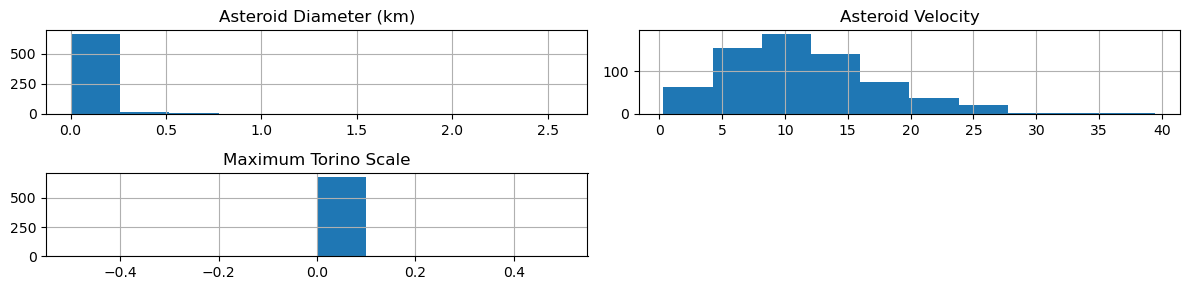

In [3]:
numeric_columns = ['Asteroid Velocity', 'Asteroid Diameter (km)', 'Cumulative Impact Probability', 'Cumulative Palermo Scale', 'Maximum Palermo Scale', 'Maximum Torino Scale']
for column in numeric_columns:
    if column in merged: merged[column] = pd.to_numeric(merged[column], errors='coerce')
display(merged[numeric_columns].isna().agg(['sum', 'mean']).T)
merged[['Asteroid Diameter (km)', 'Asteroid Velocity', 'Maximum Torino Scale']].hist(figsize=(12, 3))
plt.tight_layout(); plt.show()

## 2. Özellik mühendisliği ve fizik
Küre varsayımı, `ρ = 3000 kg/m³` yoğunluğu ve `Eₖ = 1/2mv²` kullanılır. `1 megaton TNT = 4.184 × 10¹⁵ J`.

In [4]:
DENSITY_KG_M3 = 3000.0
JOULE_PER_MEGATON_TNT = 4.184e15
for column in ['Asteroid Diameter (km)', 'Asteroid Velocity']:
    merged[column] = merged[column].fillna(merged[column].median())
merged['diameter_m'] = merged['Asteroid Diameter (km)'] * 1000
merged['velocity_m_s'] = merged['Asteroid Velocity'] * 1000
merged['volume_m3'] = (np.pi / 6) * merged['diameter_m'] ** 3
merged['mass_kg'] = merged['volume_m3'] * DENSITY_KG_M3
merged['kinetic_energy_joule'] = 0.5 * merged['mass_kg'] * merged['velocity_m_s'] ** 2
merged['energy_megaton_tnt'] = merged['kinetic_energy_joule'] / JOULE_PER_MEGATON_TNT
merged['torino_score'] = pd.to_numeric(merged['Maximum Torino Scale'], errors='coerce').fillna(0).clip(0, 10)
display(merged[['diameter_m', 'mass_kg', 'velocity_m_s', 'energy_megaton_tnt', 'torino_score']].describe())

,diameter_m,mass_kg,velocity_m_s,energy_megaton_tnt,torino_score
count,683.000000,6.830000e+02,683.000000,683.000000,683.0
mean,49.377745,6.793083e+10,11462.576867,2466.023570,0.0
std,156.402784,1.119022e+12,6067.772213,38843.788943,0.0
min,2.000000,1.256637e+04,340.000000,0.000002,0.0
25%,10.000000,1.570796e+06,7240.000000,0.010774,0.0
50%,17.000000,7.717322e+06,10500.000000,0.100682,0.0
75%,33.000000,5.644971e+07,14810.000000,1.055499,0.0
max,2579.000000,2.694473e+13,39470.000000,818934.510223,0.0


## 3-4. Ön işleme, eğitim ve değerlendirme
İki giriş değişkeni kullanıcı fonksiyonuyla tutarlıdır. Random Forest doğrusal olmayan ilişkileri öğrenir; pipeline içindeki medyan imputasyonu yeni girdileri de ele alır.

In [ ]:
FEATURES = ['diameter_m', 'velocity_m_s']
model_data = merged[FEATURES + ['energy_megaton_tnt', 'torino_score']].replace([np.inf, -np.inf], np.nan).dropna()
X = model_data[FEATURES]; y_energy = model_data['energy_megaton_tnt']; y_torino = model_data['torino_score']
X_train, X_test, y_energy_train, y_energy_test, y_torino_train, y_torino_test = train_test_split(X, y_energy, y_torino, test_size=0.20, random_state=42)
def make_model():
    return Pipeline([('imputer', SimpleImputer(strategy='median')), ('regressor', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1, min_samples_leaf=2))])
energy_model = make_model().fit(X_train, y_energy_train)
torino_model = make_model().fit(X_train, y_torino_train)
def report(name, actual, predicted):
    print(f'{name}: RMSE={np.sqrt(mean_squared_error(actual, predicted)):.4f} | MAE={mean_absolute_error(actual, predicted):.4f} | R²={r2_score(actual, predicted):.4f}')
energy_predictions = energy_model.predict(X_test)
torino_predictions = np.clip(torino_model.predict(X_test), 0, 10)
report('Megaton TNT', y_energy_test, energy_predictions)
report('Torino', y_torino_test, torino_predictions)
print('RMSE tipik hatayı, MAE mutlak ortalama hatayı, R² açıklanan varyansı gösterir; R²=1 idealdir.')

## 5. Kullanıma hazır tahmin
Fonksiyon çapı metre ve hızı km/s alır; saniyeler içinde iki tahmin döndürür.

In [ ]:
def yikicilik_tahmin_et(cap, hiz):
    if cap <= 0 or hiz <= 0: raise ValueError('cap ve hiz sifirdan buyuk olmalidir.')
    giris = pd.DataFrame({'diameter_m': [cap], 'velocity_m_s': [hiz * 1000]})
    return {'megaton_tnt_tahmini': max(0.0, float(energy_model.predict(giris)[0])), 'torino_skoru_tahmini': float(np.clip(torino_model.predict(giris)[0], 0, 10))}
print(yikicilik_tahmin_et(cap=100, hiz=20))

### Sınırlamalar
Torino değerleri çoğunlukla 0 ise sınıflandırma gücü sınırlıdır. Enerji sonucu yoğunluk ve küresel asteroid varsayımına duyarlıdır. Operasyonel kullanım için çarpma olasılığı, belirsizlikler ve atmosferik kayıplar da eklenmelidir.